In [3]:
import sys
!{sys.executable} -m pip install pdfplumber
import pdfplumber
import pandas as pd

data = []

with pdfplumber.open("fitness_dataset-1 (1).pdf") as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        for row in table[1:]:
            data.append(row)

columns = ["Date", "Steps", "Calories", "Protein", "Water", "Weight", "Exercise"]
df = pd.DataFrame(data, columns=columns)

# Cleaning
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m")
df.iloc[:,1:] = df.iloc[:,1:].astype(float)

df.head()

,Date,Steps,Calories,Protein,Water,Weight,Exercise
0,1900-01-01,5000.0,1800.0,55.0,2.5,65.0,30.0
1,1900-01-02,7000.0,1700.0,60.0,3.0,64.8,40.0
2,1900-01-03,6000.0,1750.0,58.0,2.8,64.7,35.0
3,1900-01-04,8000.0,1650.0,62.0,3.2,64.5,45.0
4,1900-01-05,7500.0,1680.0,61.0,3.0,64.3,40.0


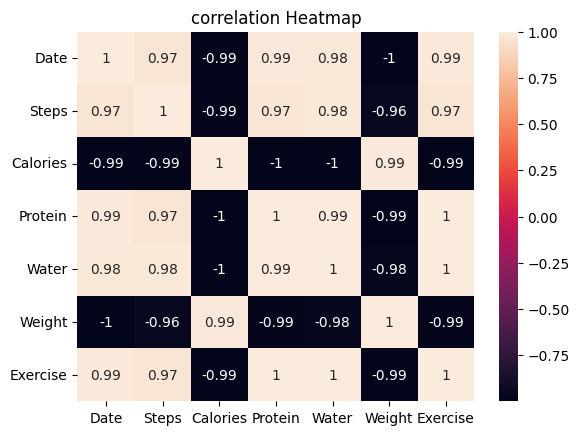

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("correlation Heatmap")
plt.show()

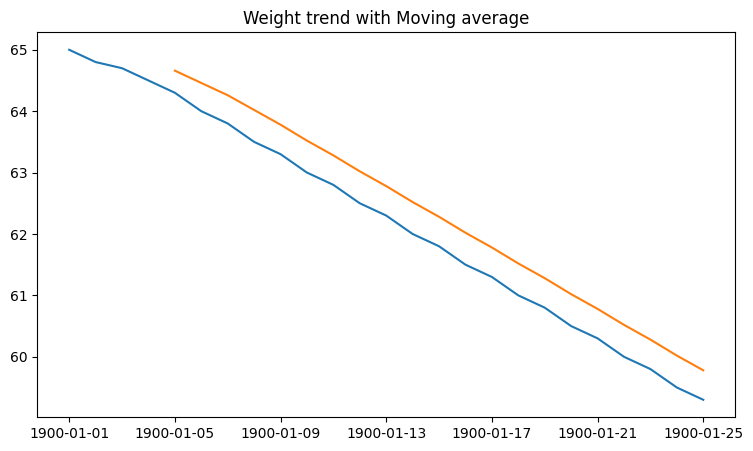

In [11]:
df["Weight_MA"]=df["Weight"].rolling(5).mean()
plt.figure(figsize=(9,5))
plt.plot(df["Date"],df["Weight"])
plt.plot(df["Date"],df["Weight_MA"])
plt.title("Weight trend with Moving average")
plt.show()

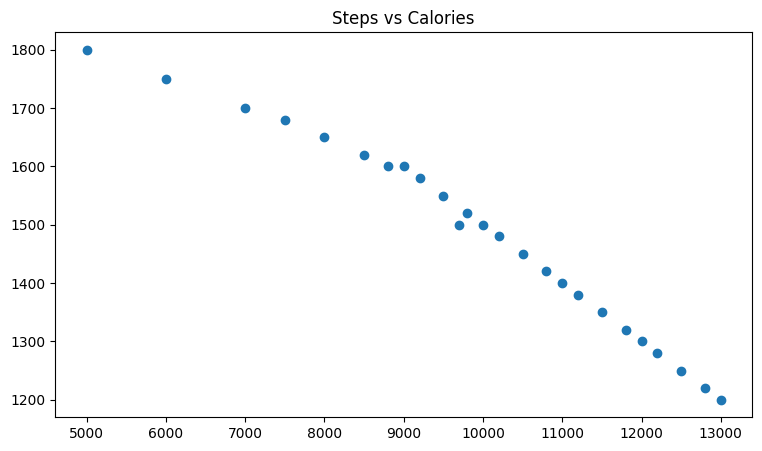

In [12]:
#STEPS VS CALORIES
plt.figure(figsize=(9,5))
plt.scatter(df["Steps"],df["Calories"])
plt.title("Steps vs Calories")
plt.show()

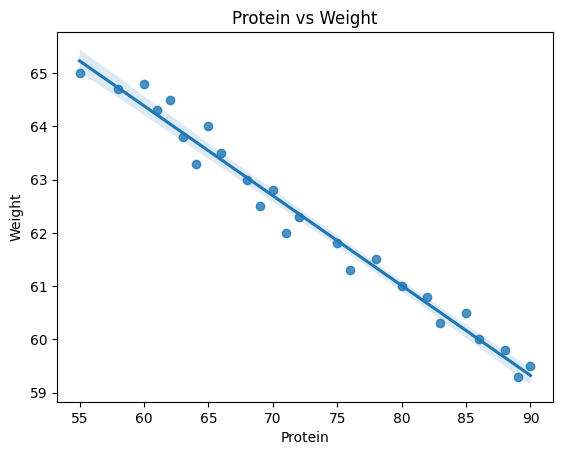

In [15]:
#PROTEIN VS WEIGHT
df['Protein'] = pd.to_numeric(df['Protein'], errors='coerce')
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
plt.figure()
sns.regplot(x="Protein", y="Weight", data=df)
plt.title("Protein vs Weight")
plt.show()

In [17]:
print("Average steps:",df['Steps'].mean())
print("Average calories:",df['Calories'].mean())
print("Average protein:",df['Protein'].mean())
print("Average weight:",df['Weight'].mean())
print("Weight Change:",
df["Weight"].iloc[0]-
df["Weight"].iloc[-1])

Average steps: 9900.0
Average calories: 1484.0
Average protein: 72.64
Average weight: 62.251999999999995
Weight Change: 5.700000000000003


In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np
df["Day"]=np.arange(len(df))
x=df[["Day"]]
y=df[["Weight"]]
model = LinearRegression()
model.fit(x,y)
#df["Weight_pred"]=model.predict(x)
future_days = np.arange(len(df), len(df)+15)
future_weights = model.predict(future_days.reshape(-1,1))
print(future_weights)

[[59.07      ]
 [58.82523077]
 [58.58046154]
 [58.33569231]
 [58.09092308]
 [57.84615385]
 [57.60138462]
 [57.35661538]
 [57.11184615]
 [56.86707692]
 [56.62230769]
 [56.37753846]
 [56.13276923]
 [55.888     ]
 [55.64323077]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


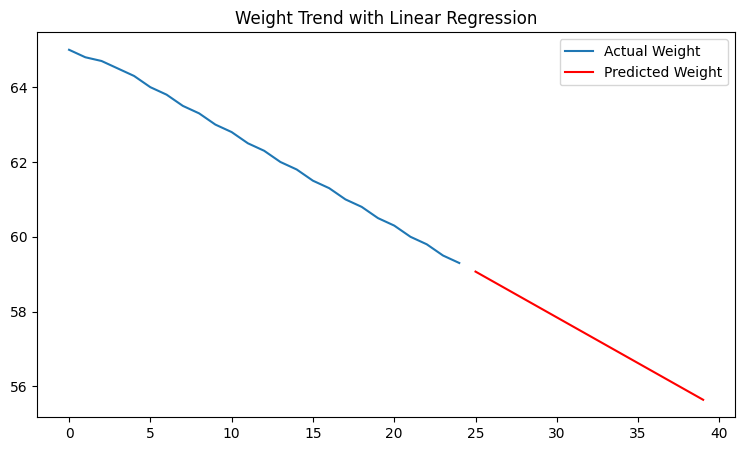

In [20]:
plt.figure(figsize=(9,5))
plt.plot(df["Day"],df["Weight"],label="Actual Weight")
plt.plot(future_days,future_weights,color="red",label="Predicted Weight")
plt.title("Weight Trend with Linear Regression")
plt.legend()
plt.show()

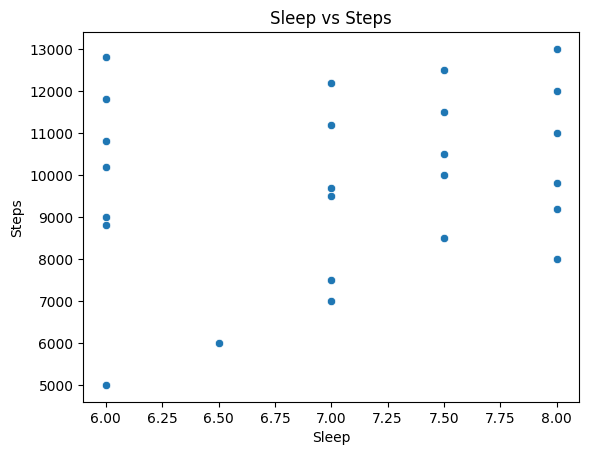

In [30]:
df["Sleep"] = [6,7,6.5,8,7,6,7.5,8,6,7,7.5,8,6,7,7.5,8,6,7,7.5,8,6,7,7.5,8,6]
import seaborn as sns
plt.figure()
sns.scatterplot(x="Sleep", y="Steps", data=df)
plt.title("Sleep vs Steps")
plt.show()

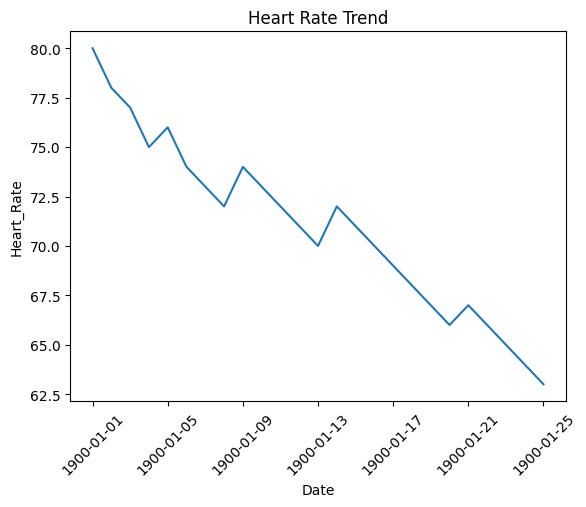

In [32]:
df["Heart_Rate"] = [80,78,77,75,76,74,73,72,74,73,72,71,70,72,71,70,69,68,67,66,67,66,65,64,63]
sns.lineplot(x="Date", y="Heart_Rate", data=df)
plt.xticks(rotation=45)
plt.title("Heart Rate Trend")
plt.show()